In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NMudwt28pae4jciiN3uu")
project = rf.workspace("s-workspace-zuwad").project("balloon-project-az6w8-fdkbf")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

model.train(
    data="/content/balloon-project-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="balloon_yolo11s"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/balloon-project-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d068ef5e240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
from ultralytics import YOLO

model = YOLO("runs/detect/balloon_yolo11s/weights/best.pt")

results = model.predict(
    source="/content/balloon-project-1/test/images",
    conf=0.5,
    save=True
)


image 1/124 /content/balloon-project-1/test/images/0001_c1s1_00151_00_png_jpg.rf.1c49f76bfb4027606e923f2b49f7d8e0.jpg: 640x640 1 YAMAFU_DEF - v5 2024-06-21 2-55pm, 15.5ms
image 2/124 /content/balloon-project-1/test/images/0001_c1s1_00176_00_png_jpg.rf.a6cbaf794cbbeebfa31c331b82c88fe4.jpg: 640x640 1 YAMAFU_DEF - v5 2024-06-21 2-55pm, 15.6ms
image 3/124 /content/balloon-project-1/test/images/0002_c1s1_00521_00_png_jpg.rf.d88b22d581e5db37b267404498208163.jpg: 640x640 1 YAMAFU_DEF - v5 2024-06-21 2-55pm, 15.5ms
image 4/124 /content/balloon-project-1/test/images/0002_c1s1_00576_00_png_jpg.rf.54eac6c5d2e44a0af423d0704423322c.jpg: 640x640 1 YAMAFU_DEF - v5 2024-06-21 2-55pm, 15.5ms
image 5/124 /content/balloon-project-1/test/images/0002_c1s1_00601_00_png_jpg.rf.2cba1c6677e7635557c5b1c61f5df286.jpg: 640x640 1 YAMAFU_DEF - v5 2024-06-21 2-55pm, 15.5ms
image 6/124 /content/balloon-project-1/test/images/0002_c1s1_00656_00_png_jpg.rf.d3e18b82713ff76f9ed8548821853837.jpg: 640x640 1 YAMAFU_DEF - v5

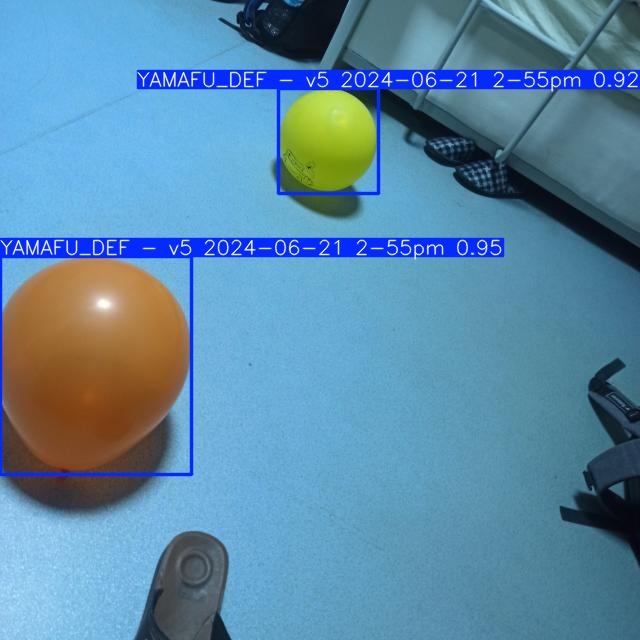

In [13]:
from IPython.display import Image
import os

result_dir = "/content/runs/detect/predict"
images = os.listdir(result_dir)

# 첫 번째 결과 이미지 출력
Image(filename=f"{result_dir}/{images[53]}")

In [11]:
from ultralytics import YOLO

model = YOLO("runs/detect/balloon_yolo11s/weights/best.pt")
model.export(format="onnx", opset=12)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'runs/detect/balloon_yolo11s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 482ms
Prepared 4 packages in 5.97s
Installed 4 packages in 318ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 7.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: 

'runs/detect/balloon_yolo11s/weights/best.onnx'

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# 구글 드라이브에 폴더 생성
os.makedirs('/content/drive/MyDrive/balloon_yolo11', exist_ok=True)

# best.onnx 복사
shutil.copy(
    'runs/detect/balloon_yolo11s/weights/best.onnx',
    '/content/drive/MyDrive/balloon_yolo11/best.onnx'
)

print("저장 완료!")

Mounted at /content/drive
저장 완료!
